In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression , Ridge , Lasso 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.max_rows', None)


In [76]:
df = pd.read_excel("premiums_young.xlsx")

In [77]:
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


In [78]:
df.shape

(20096, 13)

In [79]:
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


### Checking for NA values

In [80]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### Handeling NA values

In [81]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [82]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [83]:
print(f"Description of the dataset :")
df.describe()

Description of the dataset :


,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267
std,2.294052,0.940713,23.420493,2749.906347
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [84]:
df["number_of_dependants"] = abs(df["number_of_dependants"])
df["number_of_dependants"].describe()

count    20090.000000
mean         0.722598
std          0.937200
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: number_of_dependants, dtype: float64

In [85]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

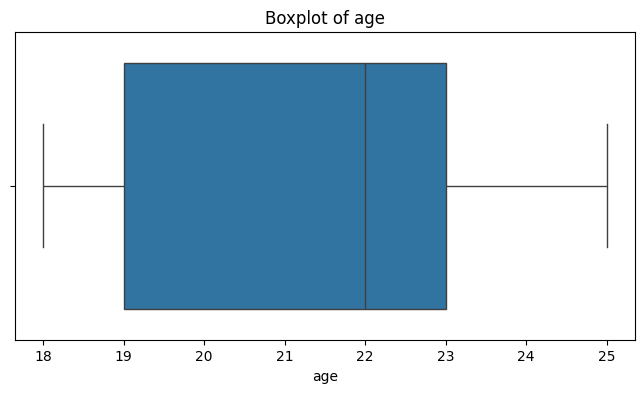

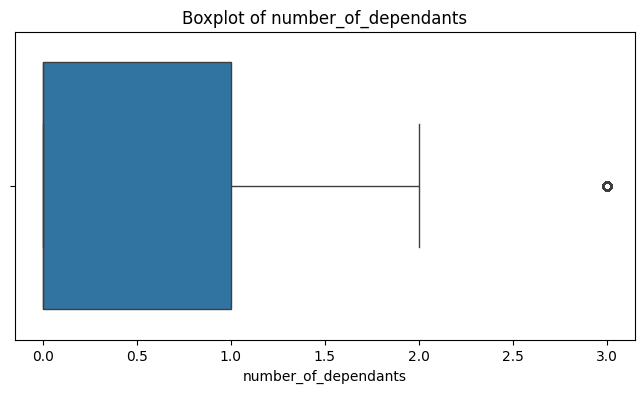

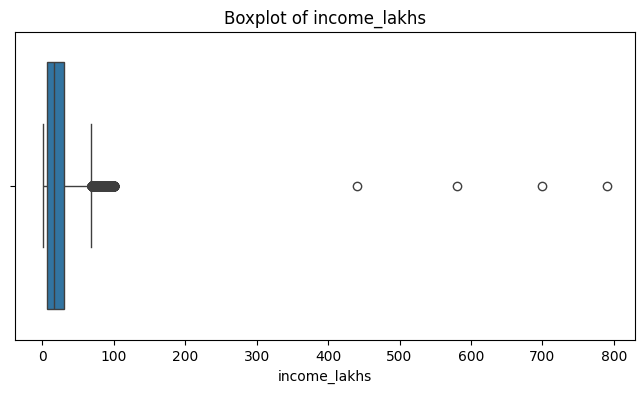

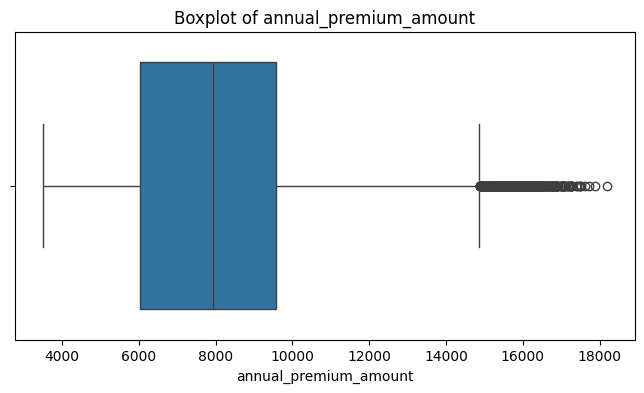

In [86]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Removing outliers of age

In [87]:
df1 = df[df.age<100].copy()

In [88]:
df1.age.describe()

count    20090.000000
mean        21.494375
std          2.294052
min         18.000000
25%         19.000000
50%         22.000000
75%         23.000000
max         25.000000
Name: age, dtype: float64

### An Function for IQR

In [89]:
def get_iqr_bounds(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [90]:
get_iqr_bounds(df1['income_lakhs'])

(np.float64(-31.5), np.float64(68.5))

In [91]:
quantile_threshold = df1['income_lakhs'].quantile(0.999)
quantile_threshold

np.float64(100.0)

In [92]:
df2 = df1[df1.income_lakhs <= quantile_threshold].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20086.000000,20086.000000,20086.000000,20086.000000
mean,21.494474,0.722742,22.390371,8141.799263
std,2.294248,0.937238,21.732062,2749.912486
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.000000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,100.000000,18186.000000


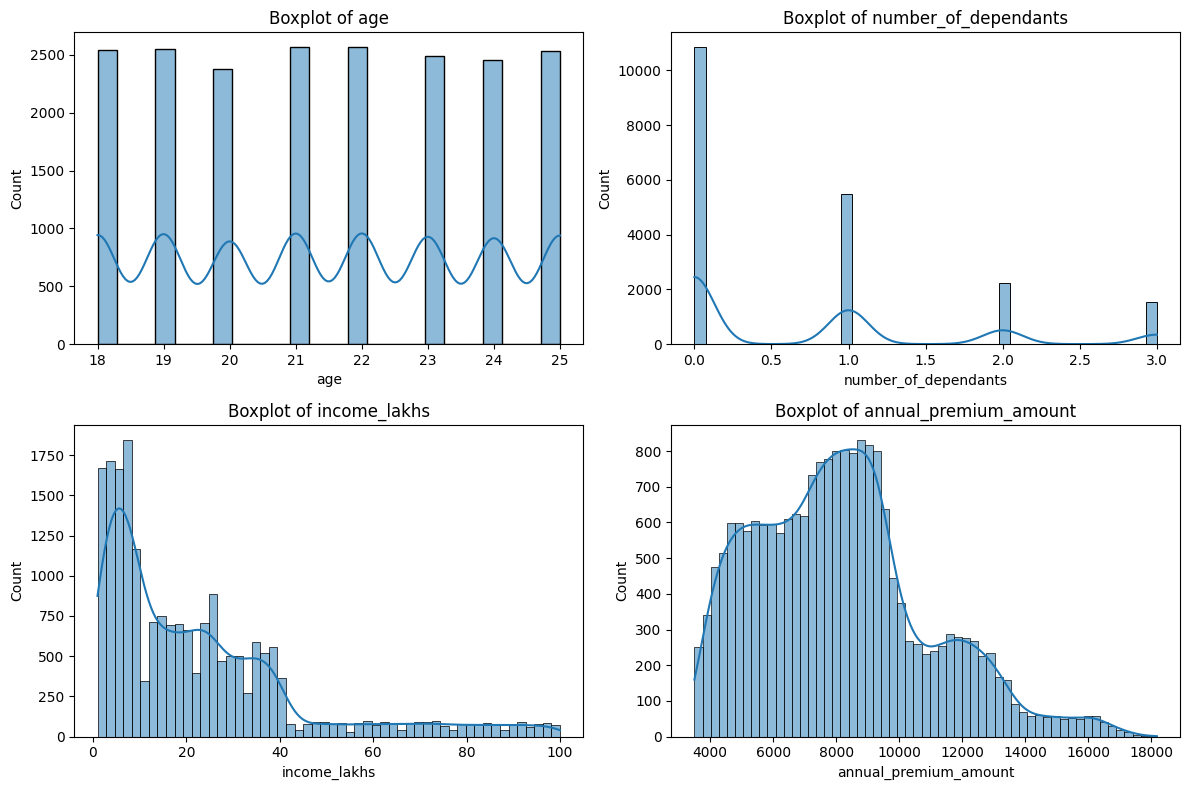

In [93]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

for i,column in enumerate(numeric_columns):
    ax = axes[i // 2, i % 2]
    sns.histplot(x=df2[column], ax=ax, kde=True)
    ax.set_title(f'Boxplot of {column}')
    
plt.tight_layout()
plt.show()

<Axes: xlabel='age', ylabel='annual_premium_amount'>

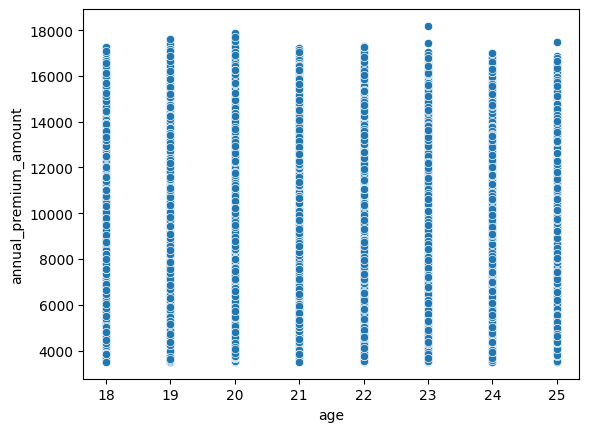

In [94]:
sns.scatterplot(data=df2, x='age', y='annual_premium_amount')

In [95]:
categorical_columns = df2.select_dtypes(include=['object']).columns

C:\Users\ittis\AppData\Local\Temp\ipykernel_12788\1042019130.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df2.select_dtypes(include=['object']).columns


In [96]:
for col in categorical_columns:
    print(f"{col} : {df2[col].unique().tolist()}")

gender : ['Male', 'Female']
region : ['Northeast', 'Northwest', 'Southeast', 'Southwest']
marital_status : ['Unmarried', 'Married']
bmi_category : ['Overweight', 'Underweight', 'Normal', 'Obesity']
smoking_status : ['Regular', 'No Smoking', 'Occasional', 'Smoking=0', 'Does Not Smoke', 'Not Smoking']
employment_status : ['Self-Employed', 'Freelancer', 'Salaried']
income_level : ['> 40L', '<10L', '10L - 25L', '25L - 40L']
medical_history : ['High blood pressure', 'No Disease', 'Diabetes & High blood pressure', 'Diabetes & Heart disease', 'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid', 'High blood pressure & Heart disease']
insurance_plan : ['Silver', 'Bronze', 'Gold']


In [97]:
df2.replace({
    'Not Smoking': 'No Smoking',
    'Smoking=0' : 'No Smoking',
    'Does Not Smoke' : 'No Smoking'
}, inplace=True)

df2['smoking_status'].unique()

<ArrowStringArray>
['Regular', 'No Smoking', 'Occasional']
Length: 3, dtype: str

In [98]:
pct_count = df2['gender'].value_counts(normalize=True)
pct_count

gender
Male      0.550383
Female    0.449617
Name: proportion, dtype: float64

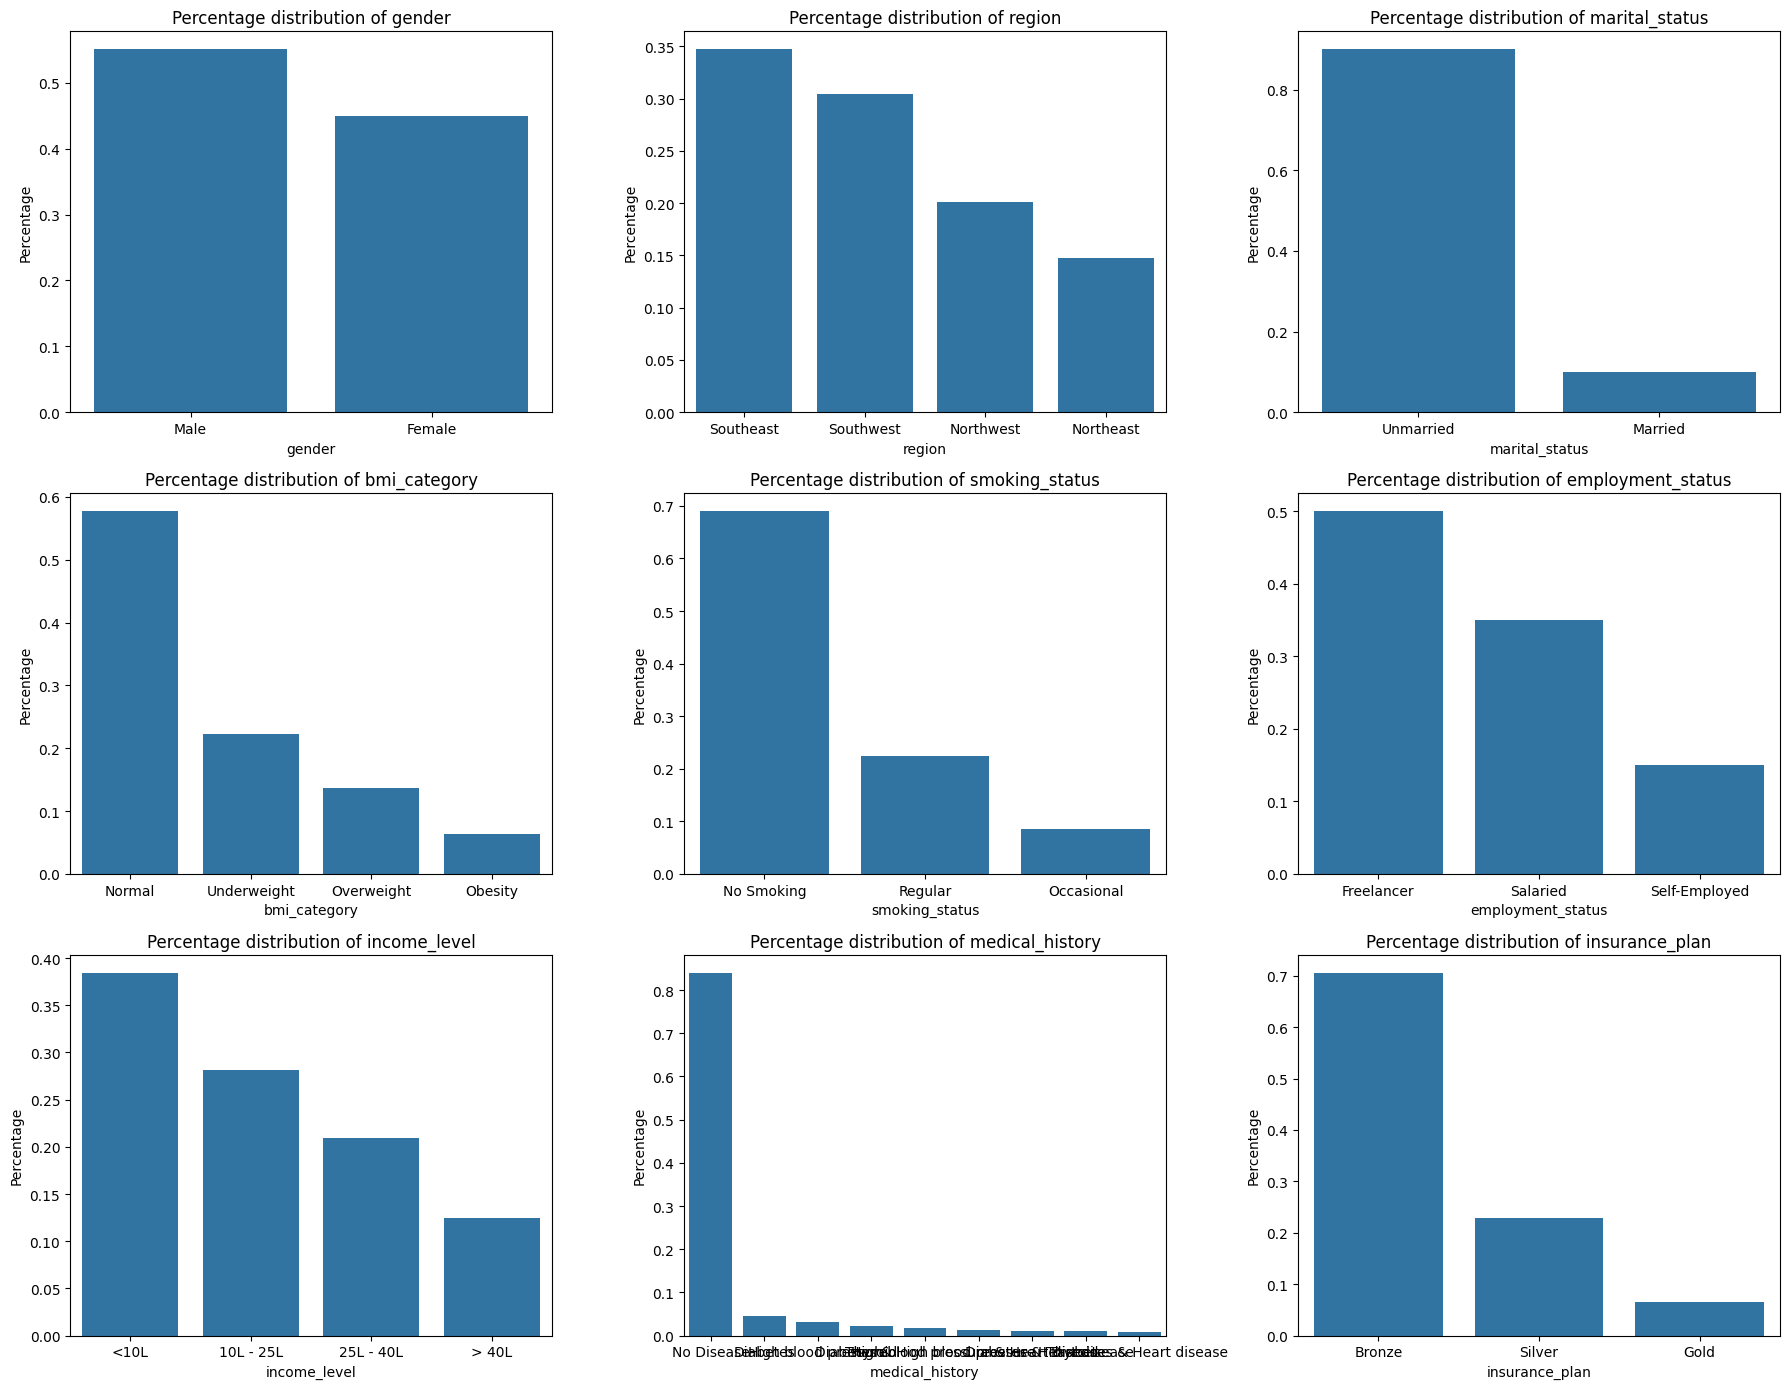

In [99]:
fig, axes = plt.subplots(3,3,figsize=(18, 14))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    category_counts = df2[column].value_counts(normalize=True)
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Percentage')
    
plt.tight_layout()
plt.show()

In [100]:
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
crosstab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,4508,326,828
25L - 40L,3382,209,608
<10L,6172,404,1145
> 40L,115,366,2023


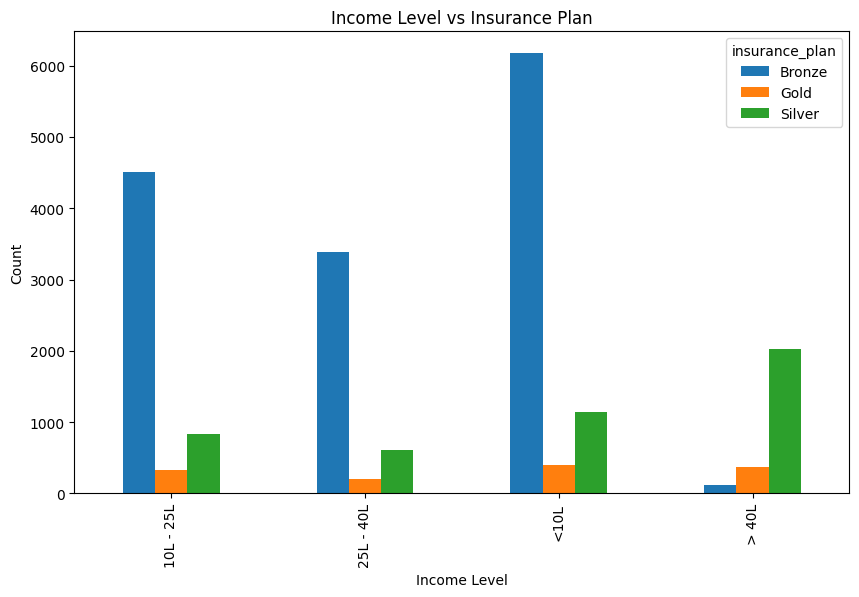

In [101]:
crosstab.plot(kind='bar', figsize=(10, 6))
plt.title('Income Level vs Insurance Plan')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='insurance_plan', ylabel='income_level'>

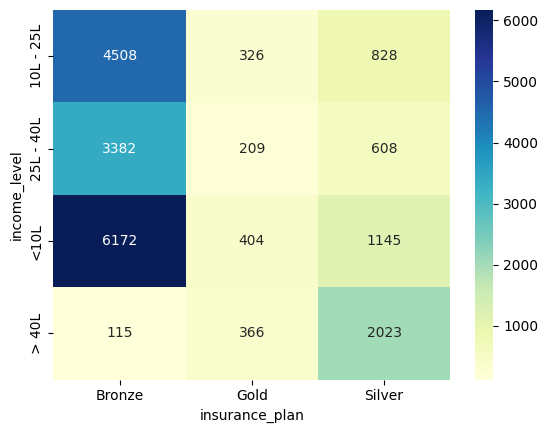

In [102]:
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')

In [103]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050


In [104]:
df2.medical_history.unique()

<ArrowStringArray>
[                'High blood pressure',                          'No Disease',
      'Diabetes & High blood pressure',            'Diabetes & Heart disease',
                            'Diabetes',                  'Diabetes & Thyroid',
                       'Heart disease',                             'Thyroid',
 'High blood pressure & Heart disease']
Length: 9, dtype: str

In [105]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df2[['disease1','disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x : x.str.lower())

In [106]:
df2['disease1'] = df2['disease1'].fillna('none')
df2['disease2'] = df2['disease2'].fillna('none')

df2['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += (
        df2[disease]
        .map(risk_scores)
        .fillna(0)
    )

min_score = df2['total_risk_score'].min()
max_score = df2['total_risk_score'].max()

df2['normalized_risk_score'] = (
    df2['total_risk_score'] - min_score
) / (max_score - min_score)

df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,no disease,none,0,0.000000
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,no disease,none,0,0.000000
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,no disease,none,0,0.000000
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,no disease,none,0,0.000000


###  Encoding the Categorical columns

In [107]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [108]:
df2.income_level.unique()

<ArrowStringArray>
['> 40L', '<10L', '10L - 25L', '25L - 40L']
Length: 4, dtype: str

In [109]:

df2['income_level'] = df2['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [110]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)
df3.head(3)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,high blood pressure,none,6,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,no disease,none,0,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,no disease,none,0,...,1,0,1,0,0,0,0,1,1,0


In [111]:
df4 = df3.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)
df4.head(3)                

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0


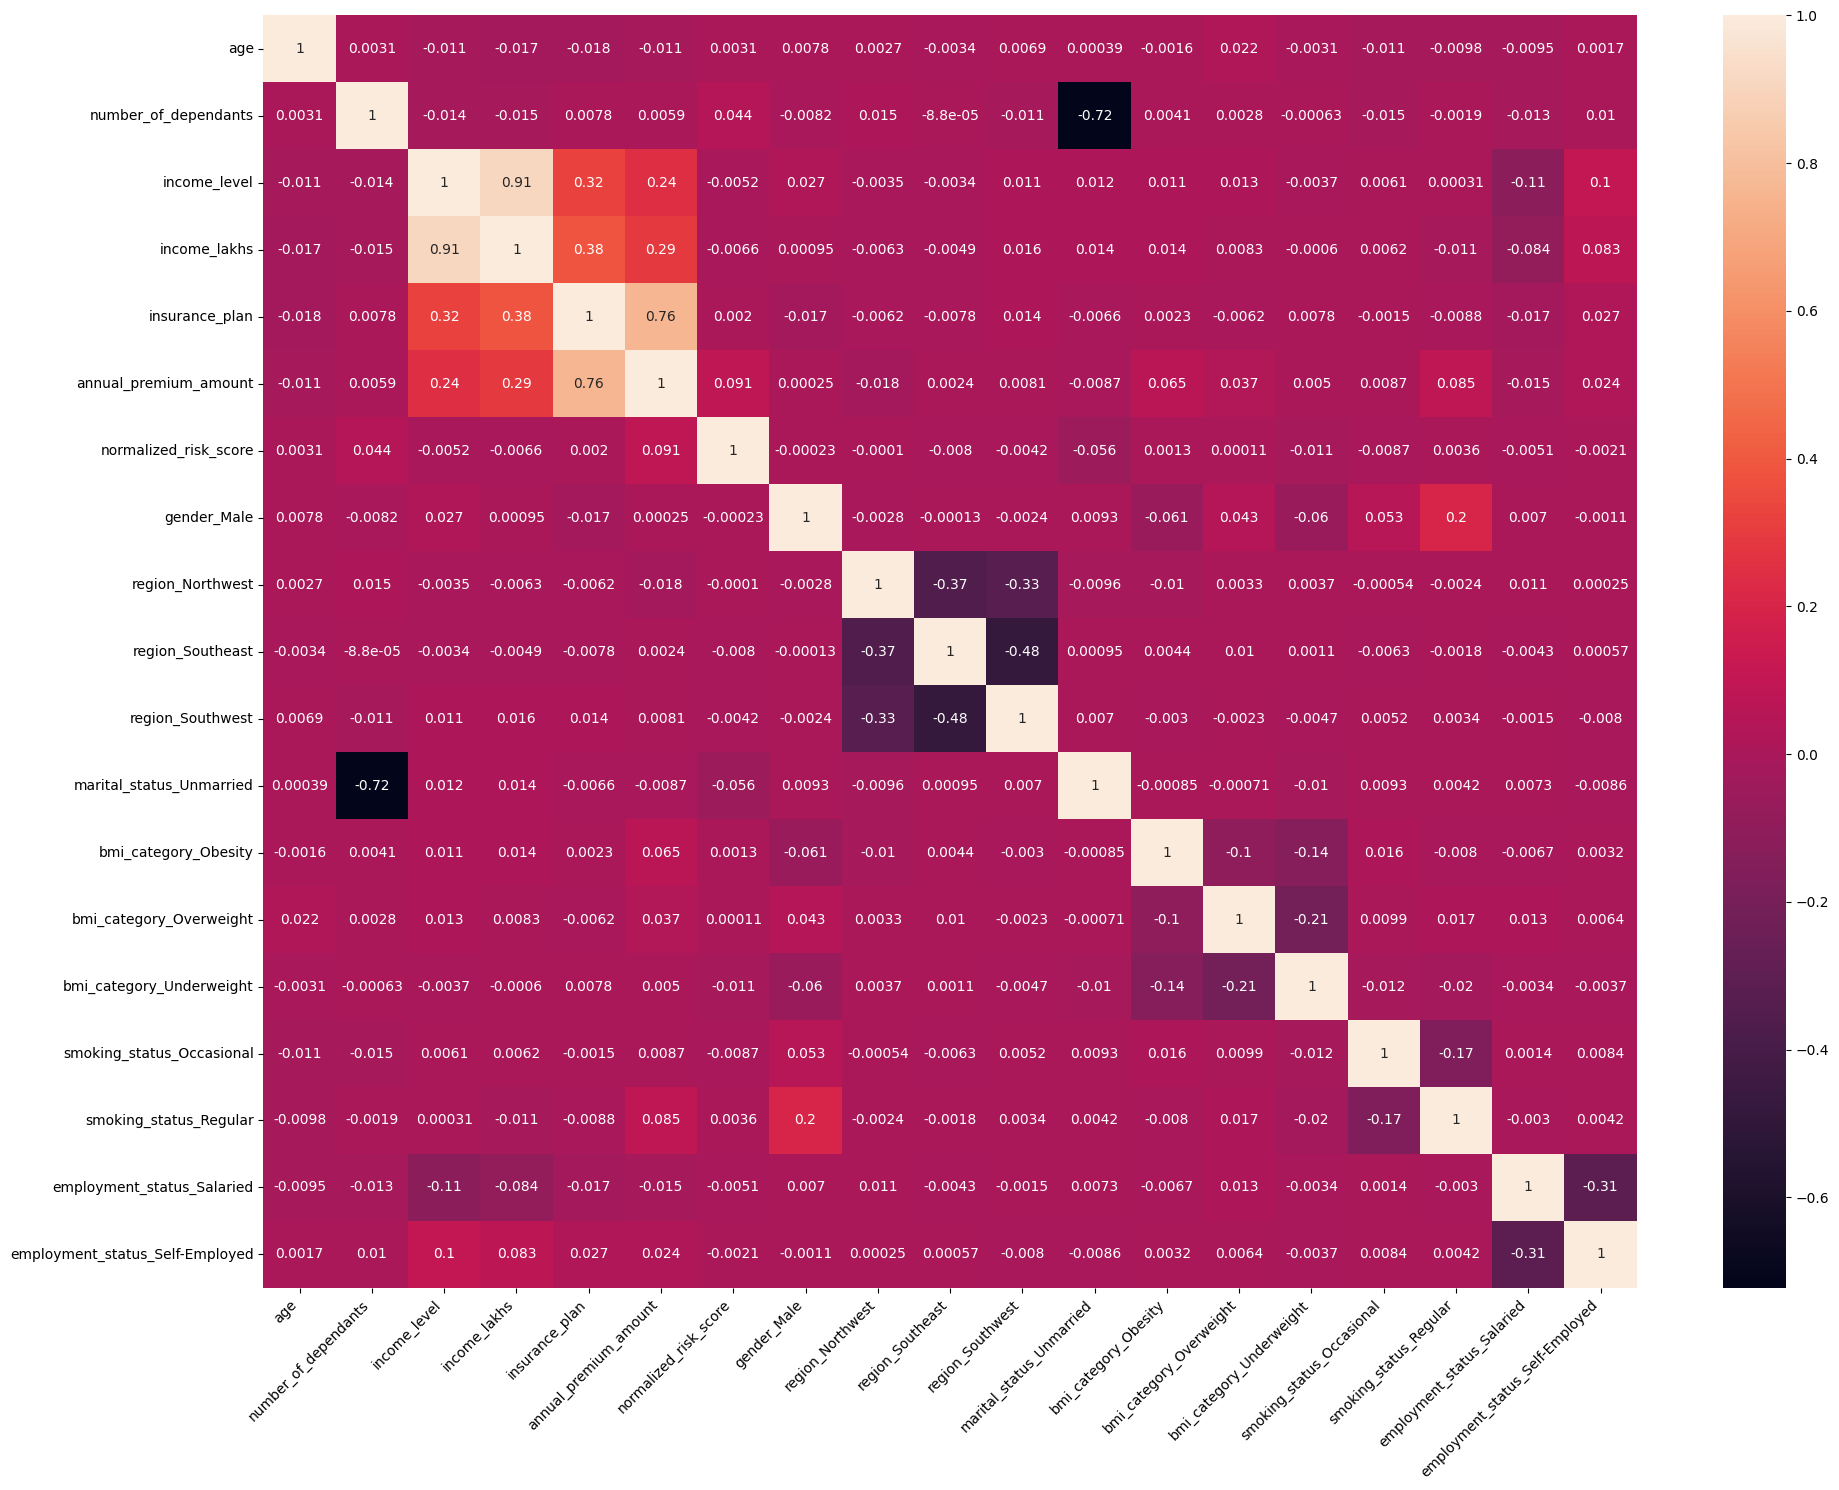

In [112]:
cm = df4.corr()

plt.figure(figsize=(20,15))
sns.heatmap(cm, annot=True)
plt.xticks(rotation = 45 , ha = 'right')
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()


 <h2 align="center" style="color:Yellow">Feature Engineering</h2>

In [113]:
df4.head(7)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,1,5684,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,1,5712,0.000000,1,0,1,0,1,0,1,0,0,0,0,0
5,22,0,3,30,3,15473,0.428571,0,0,0,1,1,0,0,1,0,1,0,0
6,19,0,1,8,1,4097,0.000000,1,0,0,1,1,0,0,0,0,0,0,0


In [114]:
X = df4.drop('annual_premium_amount', axis='columns')
y = df4['annual_premium_amount']

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,0.499211,0.240914,0.357994,0.216064,0.179578,0.092076,0.550383,0.201284,0.346958,0.304590,0.899881,0.063527,0.136513,0.222493,0.086379,0.223589,0.350045,0.149955
std,0.327750,0.312413,0.347481,0.219516,0.300051,0.230016,0.497467,0.400970,0.476014,0.460245,0.300167,0.243914,0.343341,0.415931,0.280929,0.416660,0.476996,0.357036
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.050505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.571429,0.000000,0.333333,0.151515,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.303030,0.500000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [115]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [116]:
calculate_vif(X)

,Column,VIF
0,age,1.001650
1,number_of_dependants,2.095015
2,income_level,5.800393
3,income_lakhs,6.032052
4,insurance_plan,1.175315
5,normalized_risk_score,1.003803
6,gender_Male,1.064643
7,region_Northwest,1.892615
8,region_Southeast,2.194181
9,region_Southwest,2.136452


In [117]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,age,1.001575
1,number_of_dependants,2.094973
2,income_lakhs,1.183551
3,insurance_plan,1.171263
4,normalized_risk_score,1.003800
5,gender_Male,1.061084
6,region_Northwest,1.892571
7,region_Southeast,2.194171
8,region_Southwest,2.136448
9,marital_status_Unmarried,2.096715


In [118]:
X_reduced = X.drop('income_level', axis="columns")

<h2 align="center" style="color:Yellow">Model Training</h2>

In [119]:
X_train , X_test , y_train , y_test = train_test_split(X_reduced, y , test_size= 0.25, random_state=20)
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (15064, 17)
x test:  (5022, 17)
y train:  (15064,)
y test:  (5022,)


In [120]:
model_lr = LinearRegression()
model_lr.fit(X_train,y_train)
model_lr.score(X_test,y_test)


0.5978568965594067

In [121]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  2981231.343152511 RMSE:  1726.6242622969569


In [122]:
feature_importance = model_lr.coef_

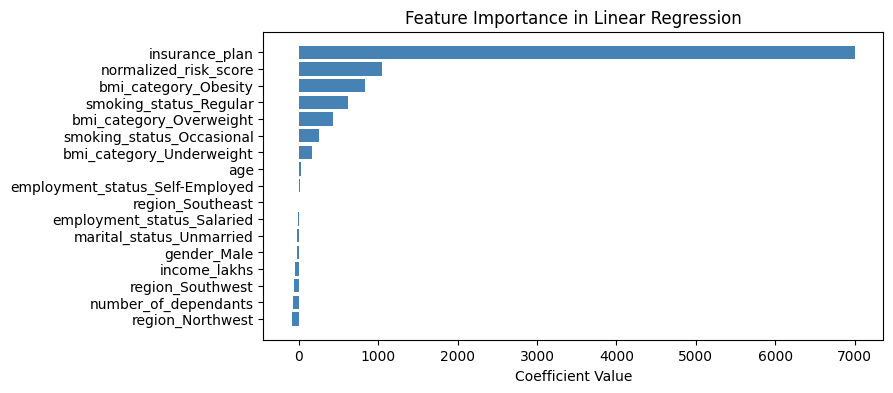

In [123]:

coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])


coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

<h2 align="center" style="color:Yellow">Ridge Regression Model</h2>

In [124]:
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.6046220258531592, 0.5978712069360541)

In [125]:
y_pred = model_rg.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Ridge Regression ==> MSE:  2981125.255187733 RMSE:  1726.593540816058


<h2 align="center" style="color:Yellow">XGBOOST Regression Model</h2>

In [126]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.597135066986084

In [127]:
y_pred = model_xgb.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

XGBoost Regression ==> MSE:  2986582.75 RMSE:  1728.1732407371665


In [128]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.6013780037562052)

In [129]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}

In [130]:
best_model = random_search.best_estimator_

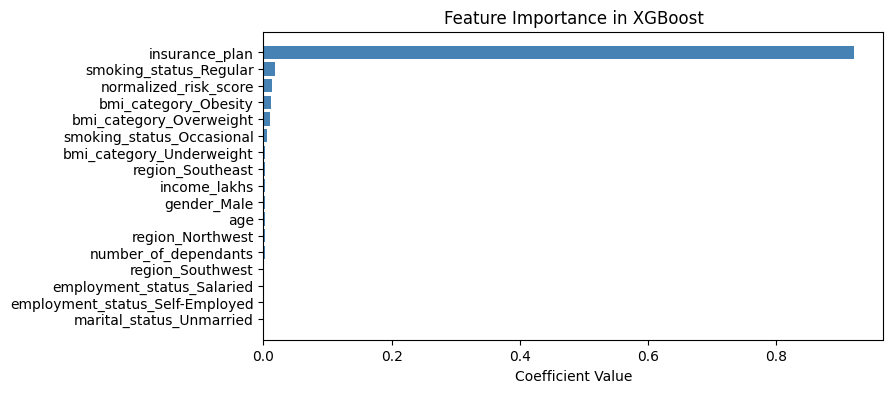

In [131]:
feature_importance = best_model.feature_importances_


coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

<h2 align="center" style="color:Yellow">Error Calculation</h2>

In [132]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = residuals*100/y_test

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
19483,7771,6698.403320,-1072.596680,-13.802557
5375,8193,6622.550781,-1570.449219,-19.168183
12632,7181,6911.875000,-269.125000,-3.747737
5520,6118,7401.801758,1283.801758,20.984010
7324,12983,10710.666992,-2272.333008,-17.502372


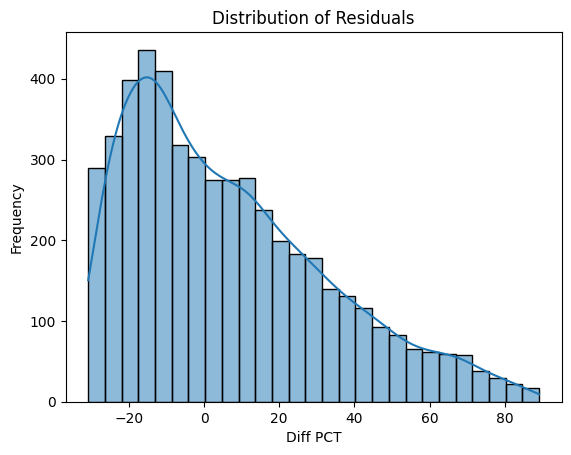

In [133]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [134]:
extreme_error_threshold = 10

extreme_results_df = results_df[np.abs(results_df.diff_pct)> extreme_error_threshold] 
extreme_results_df.shape

(3670, 4)

In [135]:
extreme_results_df.shape[0]*100/results_df.shape[0]

73.0784547988849

In [136]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct
14598,3501,6622.550781,3121.550781,89.161690
12058,3503,6608.030762,3105.030762,88.639188
641,3522,6622.550781,3100.550781,88.033810
19094,3531,6622.550781,3091.550781,87.554539
14214,3514,6584.100098,3070.100098,87.367675
...,...,...,...,...
4641,4495,6755.016113,2260.016113,50.278445
16130,4563,6856.780273,2293.780273,50.269127
13389,4656,6991.902832,2335.902832,50.169734
1601,5316,7979.163574,2663.163574,50.097133


In [137]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
19483,0.857143,0.000000,0.000000,0.0,0.000000,1,0,1,0,1,0,0,1,0,0,1,0
5375,0.285714,0.000000,0.080808,0.0,0.000000,0,0,1,0,1,0,0,0,0,0,1,0
5520,0.142857,0.333333,0.191919,0.0,0.428571,1,0,0,0,1,1,0,0,0,0,0,1
7324,1.000000,0.000000,0.171717,0.5,0.000000,1,0,1,0,1,0,0,0,0,1,1,0
7293,0.285714,0.333333,0.343434,0.0,0.000000,1,0,0,1,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113,0.428571,0.000000,0.080808,0.0,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
5924,0.571429,0.000000,0.333333,0.0,0.428571,1,0,1,0,1,0,0,0,0,1,0,0
19755,0.857143,0.000000,0.272727,0.0,0.000000,1,0,0,1,1,0,0,0,0,1,0,0
3504,0.428571,0.000000,0.080808,0.0,0.000000,1,0,1,0,1,0,0,0,0,0,0,0


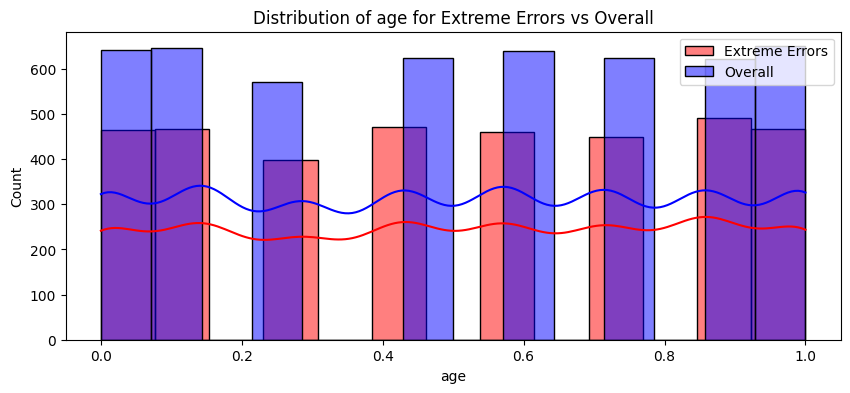

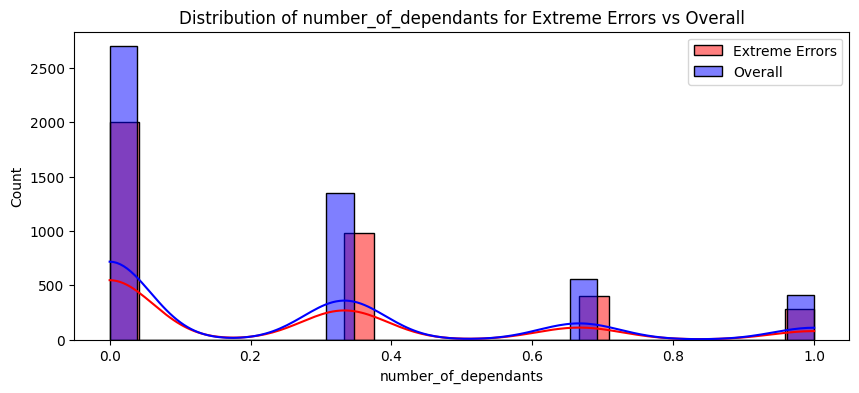

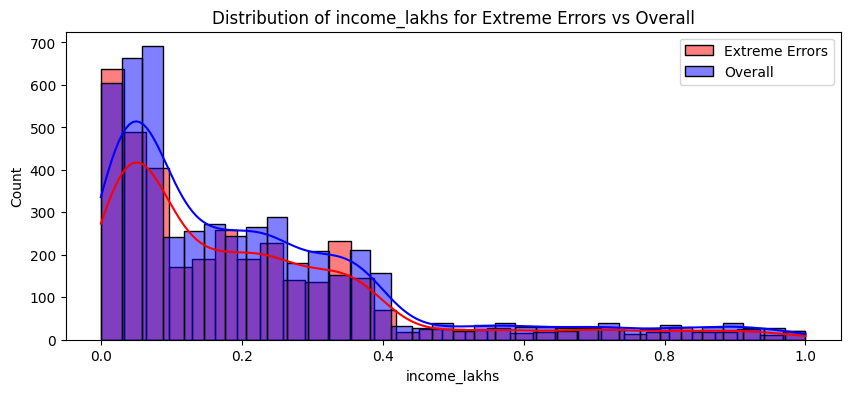

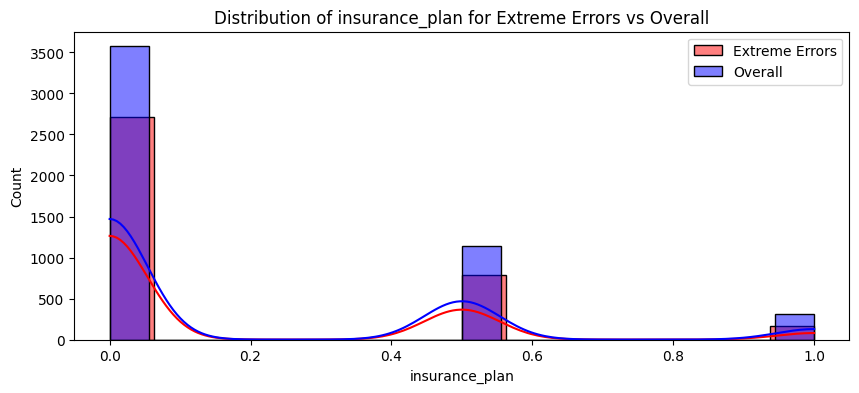

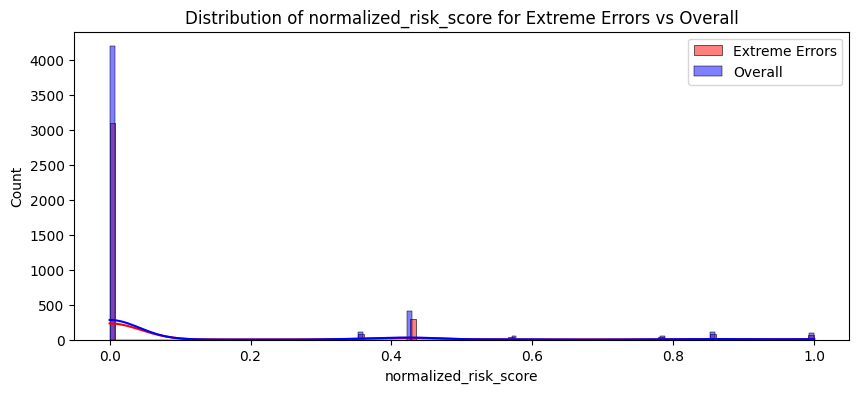

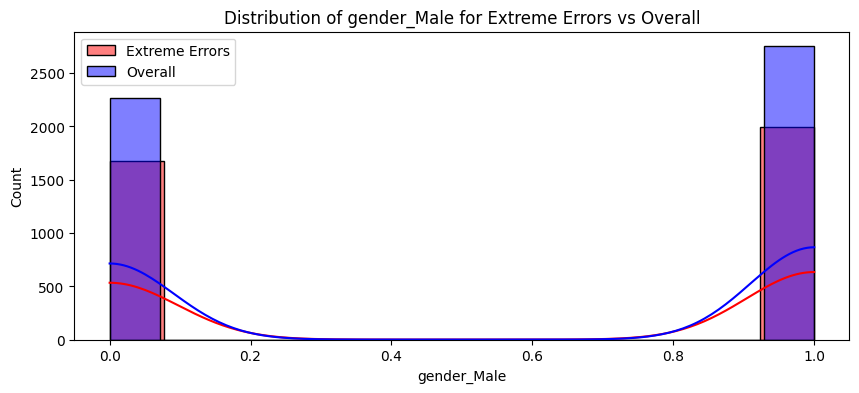

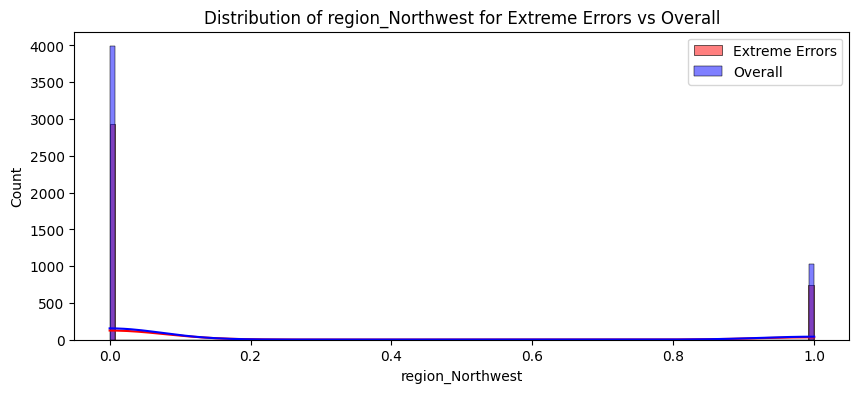

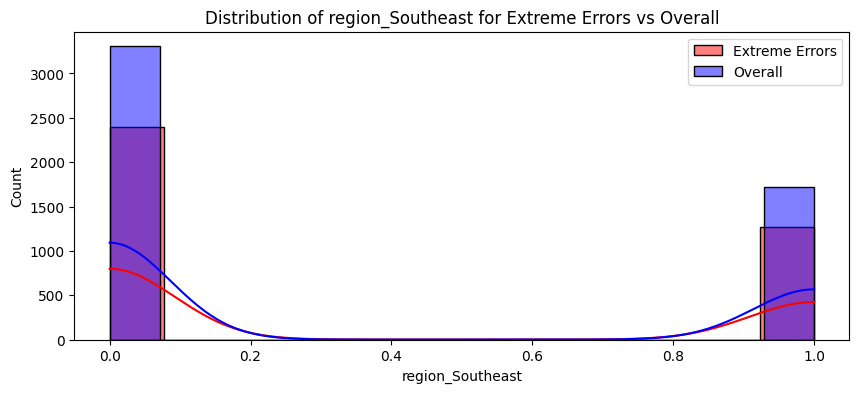

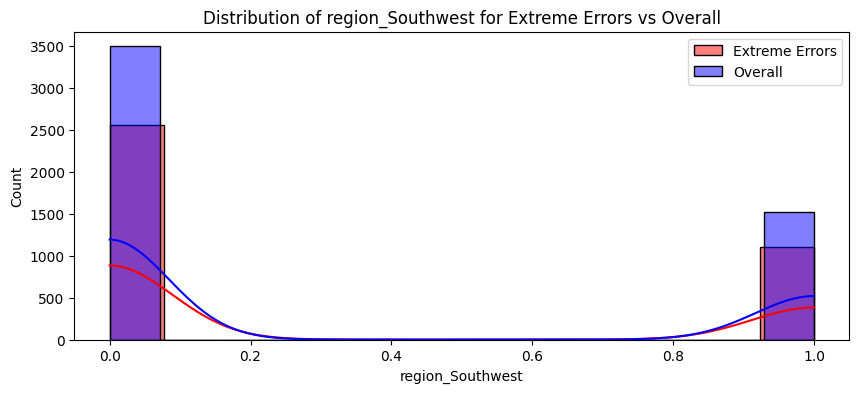

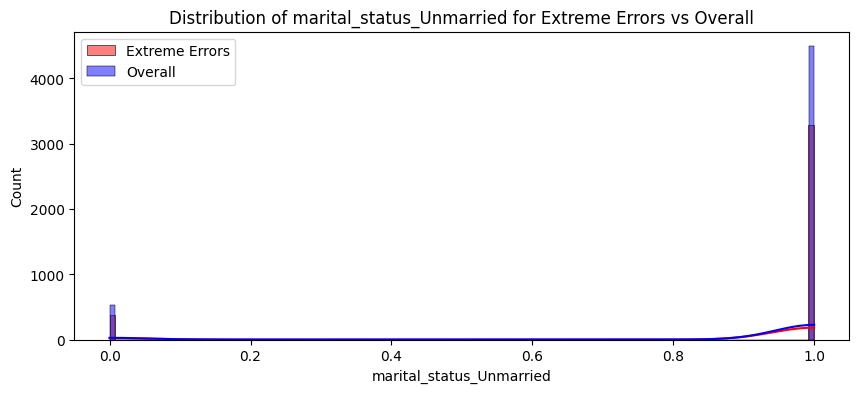

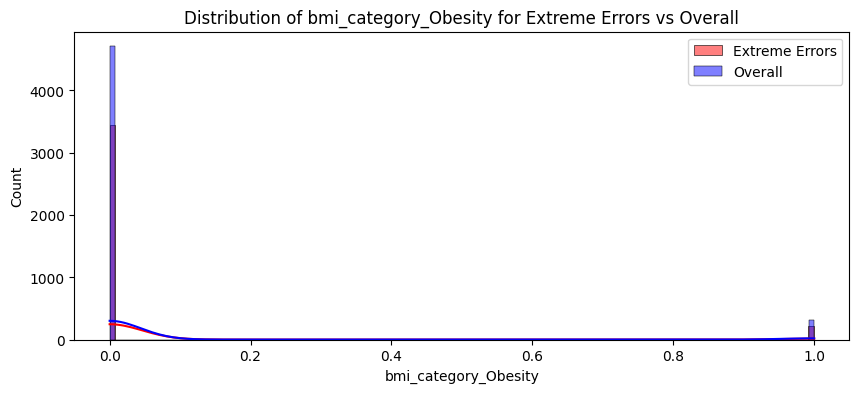

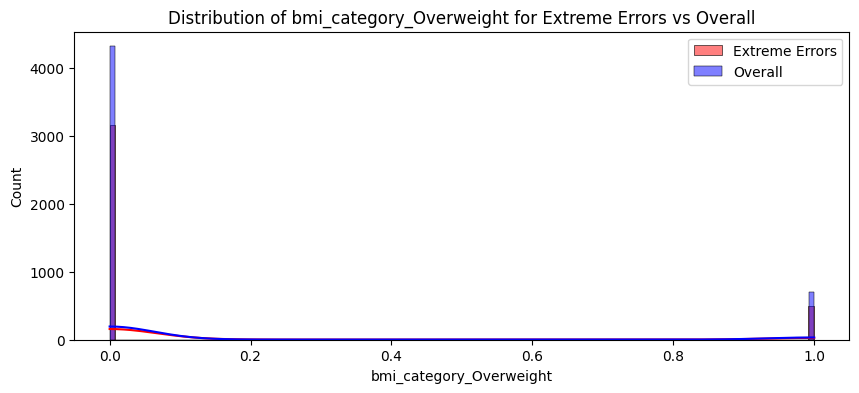

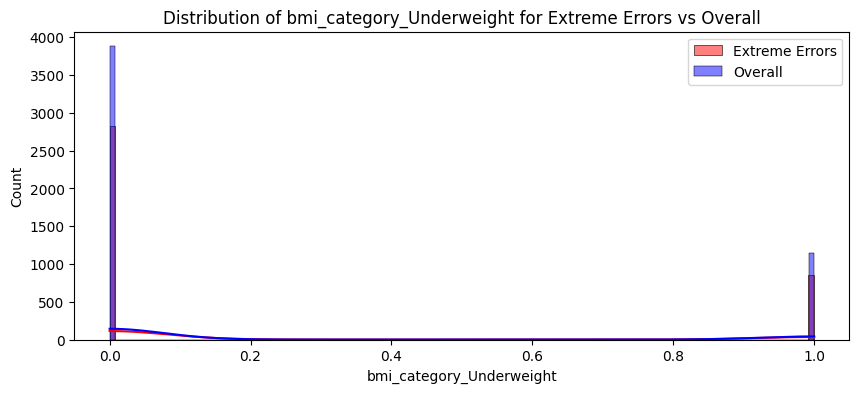

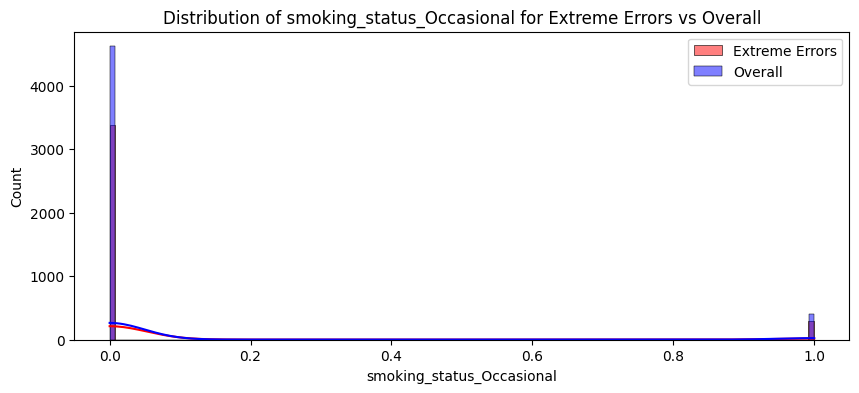

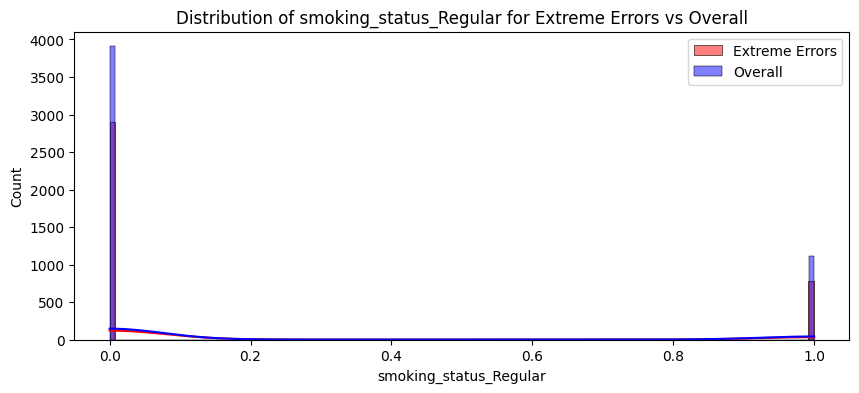

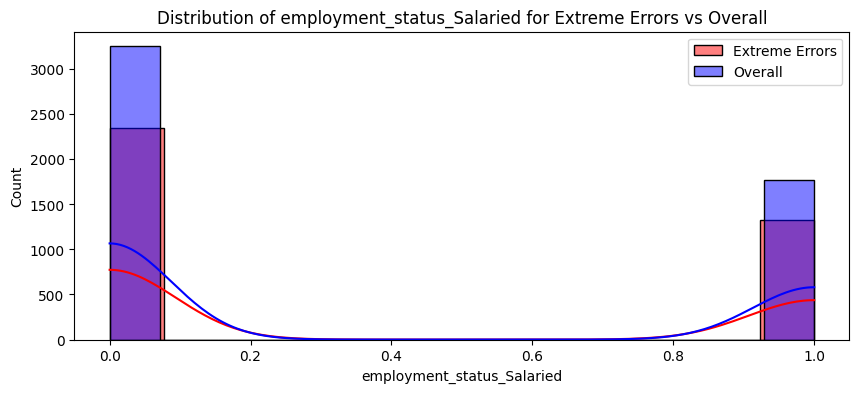

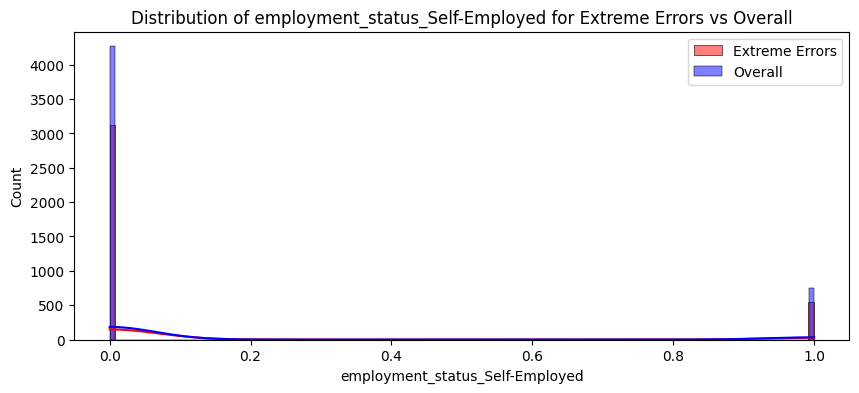

In [138]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

# reverse scaling

In [139]:
extreme_errors_df['income_level']=-1

In [140]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,24.0,0.0,-2.0,1.0,1.0
1,20.0,0.0,-2.0,9.0,1.0
2,19.0,1.0,-2.0,20.0,1.0
3,25.0,0.0,-2.0,18.0,2.0
4,20.0,1.0,-2.0,35.0,1.0


In [141]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,3670.000000,3670.000000,3670.0,3670.000000,3670.000000
mean,21.538965,0.720436,-2.0,21.518529,1.306812
std,2.307035,0.942207,0.0,20.699305,0.553127
min,18.000000,0.000000,-2.0,1.000000,1.000000
25%,19.000000,0.000000,-2.0,6.000000,1.000000
50%,22.000000,0.000000,-2.0,16.000000,1.000000
75%,24.000000,1.000000,-2.0,31.000000,2.000000
max,25.000000,3.000000,-2.0,100.000000,3.000000


<Axes: xlabel='age', ylabel='Count'>

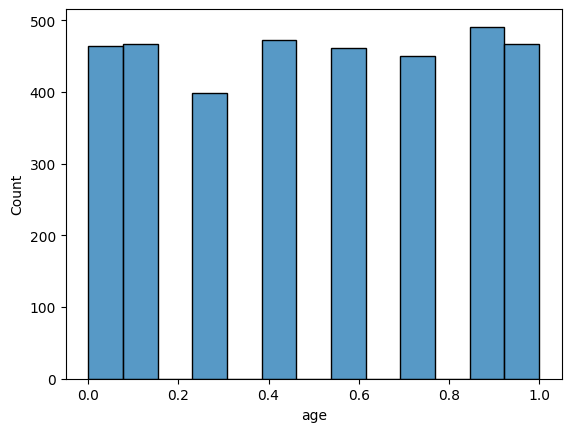

In [142]:
sns.histplot(extreme_errors_df.age)

<Axes: xlabel='age', ylabel='Count'>

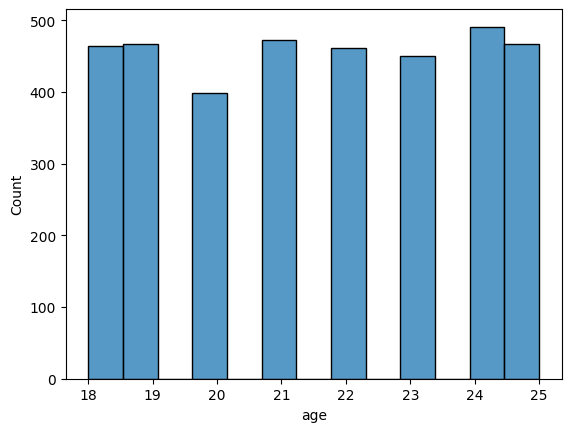

In [143]:
sns.histplot(df_reversed.age)